# BE m228 Final Project

### Load Libraries & Data

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score, f1_score
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
from sklearn.metrics import recall_score, precision_score, confusion_matrix

from ucimlrepo import fetch_ucirepo 



In [93]:
diabetes_data = fetch_ucirepo(id=891)

X = diabetes_data.data.features 
X = X.drop('GenHlth', axis=1)
y = diabetes_data.data.targets

df = pd.DataFrame(X, columns=diabetes_data.variables['name'])
df['Diabetes_binary'] = y
df['ID'] = diabetes_data.data.ids
df.head(3)

name,ID,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,0,1,1,1,40,1,0,0,0,...,1,0,NaN,18,15,1,0,9,4,3
1,1,0,0,0,0,25,1,0,0,1,...,0,1,NaN,0,0,0,0,7,6,1
2,2,0,1,1,1,28,0,0,0,0,...,1,1,NaN,30,30,1,0,9,4,8


In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## Random Forest Model

In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(class_weight="balanced", random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "max_features": ["sqrt"]
}

# this optimization takes ~4 minutes to run, so commented out for now; best params are n_estimators=200, max_depth=10, max_features="sqrt"
# grid = GridSearchCV(rf, param_grid, cv=3, scoring="f1", n_jobs=-1)
# grid.fit(X_train, y_train)

# print(grid.best_params_)

In [96]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight="balanced", max_features="sqrt")
rf_model.fit(X_train, y_train)
rf_y_preds = rf_model.predict(X_test)

print(classification_report(y_test, rf_y_preds))

/Users/estw314/Documents/EstherFiles/mdm/m228-final-project/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

           0       0.95      0.71      0.81     43667
           1       0.30      0.76      0.43      7069

    accuracy                           0.72     50736
   macro avg       0.62      0.73      0.62     50736
weighted avg       0.86      0.72      0.76     50736



In [97]:
rf_y_train_probs = rf_model.predict_proba(X_train)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_train, rf_y_train_probs)

# calculate F1 for every threshold
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]

#print(f"Optimal Threshold found: {best_threshold:.4f}")

In [98]:
rf_best_threshold = 0.6201
rf_test_probs = rf_model.predict_proba(X_test)[:, 1]

# apply the custom threshold
rf_test_preds = (rf_test_probs >= rf_best_threshold).astype(int)

#### Model Metrics

In [99]:
tn, fp, fn, tp = confusion_matrix(y_test, rf_test_preds).ravel()

precision = tp / (tp + fp)
recall = tp / (tp + fn) # sensitivity
specificity = tn / (tn + fp)
accuracy = (tp + tn) / (tp + fp + tn + fn)

print(f'precision of model: {precision}')
print(f'recall of model: {recall}')
print(f'specificity of model: {specificity}')
print(f'accuracy of model: {accuracy}')

precision of model: 0.3689731321310269
recall of model: 0.5672655255340218
specificity of model: 0.8429477637575286
accuracy of model: 0.8045372122358877


In [100]:
pr_auc = average_precision_score(y_test, rf_test_probs)
brier_score = brier_score_loss(y_test, rf_test_probs)
roc_auc = roc_auc_score(y_test, rf_test_probs)
f1 = f1_score(y_test, rf_test_preds)

print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"Brier Score (Calibration): {brier_score:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"F1-Score: {f1:.4f}")

PR-AUC (Average Precision): 0.3933
Brier Score (Calibration): 0.1773
ROC-AUC: 0.8072
F1-Score: 0.4471


## XGBoost

Finding best parameters

In [101]:
from xgboost import XGBClassifier

ratio = (y_train.values == 0).sum() / (y_train.values == 1).sum()

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200]
}

xgb_model = XGBClassifier(
    scale_pos_weight=ratio, 
    eval_metric='logloss',
    random_state=42
)

# optimization commented out to save time; best params are max_depth=3, learning_rate=0.1, n_estimators=100
# grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring='f1', cv=3, verbose=1)
# grid_search.fit(X_train, y_train)

# print(f"Best Parameters: {grid_search.best_params_}")
# print(f"Best F1-Score from GridSearch: {grid_search.best_score_:.4f}")

Training, fitting, and predicting:

In [102]:
from sklearn.model_selection import StratifiedKFold, cross_validate

ratio = (y_train.values == 0).sum() / (y_train.values == 1).sum()

# initialize the Stratified K-Fold object
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# initialize the model 
# add scale_pos_weight to handle the imbalance during training
xg_model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate = 0.1, scale_pos_weight=ratio, eval_metric='logloss', random_state=42)

# run cross-validation
# use 'f1' or 'roc_auc' because 'accuracy' is misleading for imbalanced data
cv_results = cross_validate(xg_model, X_train, y_train.values.ravel(), cv=skf, scoring=['roc_auc', 'f1', 'average_precision'])

In [103]:
xg_model.fit(X_train, y_train.values.ravel())

# find the best threshold using the training data
xg_y_train_probs = xg_model.predict_proba(X_train)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_train, xg_y_train_probs)

# calculate F1 for every threshold
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Optimal Threshold found: {best_threshold:.4f}")

Optimal Threshold found: 0.6357


In [104]:
xg_test_probs = xg_model.predict_proba(X_test)[:, 1]

# apply the custom threshold
xg_test_preds = (xg_test_probs >= best_threshold).astype(int)

#### Model Metrics

In [105]:
tn, fp, fn, tp = confusion_matrix(y_test, xg_test_preds).ravel()

precision = tp / (tp + fp)
recall = tp / (tp + fn) # sensitivity
specificity = tn / (tn + fp)
accuracy = (tp + tn) / (tp + fp + tn + fn)

print(f'precision of model: {precision}')
print(f'recall of model: {recall}')
print(f'specificity of model: {specificity}')
print(f'accuracy of model: {accuracy}')

precision of model: 0.36379370024229835
recall of model: 0.5947092941010044
specificity of model: 0.8316348730162365
accuracy of model: 0.7986242510249133


In [106]:
pr_auc = average_precision_score(y_test, xg_test_probs)
brier_score = brier_score_loss(y_test, xg_test_probs)
roc_auc = roc_auc_score(y_test, xg_test_probs)
f1 = f1_score(y_test, xg_test_preds)

print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"Brier Score (Calibration): {brier_score:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"F1-Score: {f1:.4f}")

PR-AUC (Average Precision): 0.3991
Brier Score (Calibration): 0.1817
ROC-AUC: 0.8110
F1-Score: 0.4514


### Comparing the Models

ROC curves

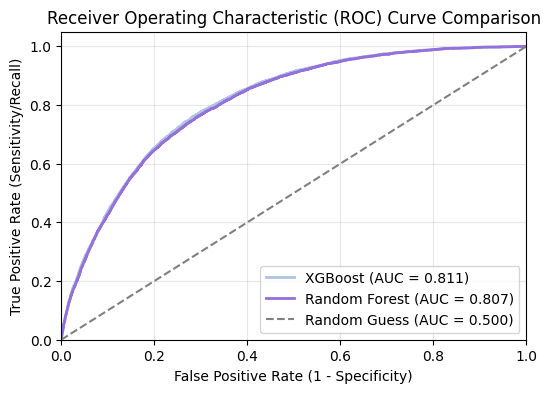

In [107]:
# calculate points for the XGBoost Curve
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xg_test_probs)
xgb_auc = roc_auc_score(y_test, xg_test_probs)

# calculate points for the Random Forest Curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_test_probs)
rf_auc = roc_auc_score(y_test, rf_test_probs)

plt.figure(figsize=(6, 4))
# plot xgboost
plt.plot(xgb_fpr, xgb_tpr, color='lightsteelblue', lw=2, 
         label=f'XGBoost (AUC = {xgb_auc:.3f})')
# plot random forest
plt.plot(rf_fpr, rf_tpr, color='mediumpurple', lw=2, 
         label=f'Random Forest (AUC = {rf_auc:.3f})')
# plot the "Random Guess" diagonal line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.500)')

# format plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Confusion Matrices

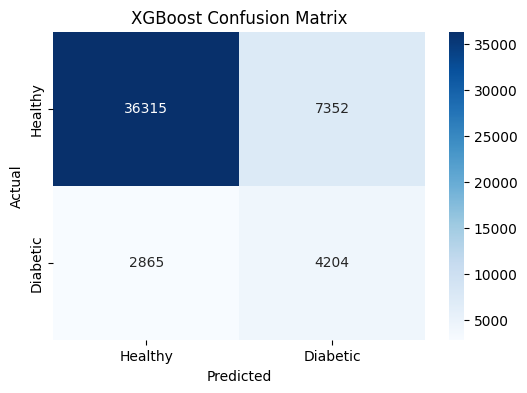

In [108]:
xg_cm = confusion_matrix(y_test, xg_test_preds)
plt.figure(figsize=(6,4))
sns.heatmap(xg_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Diabetic'], yticklabels=['Healthy', 'Diabetic'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('XGBoost Confusion Matrix')
plt.show()

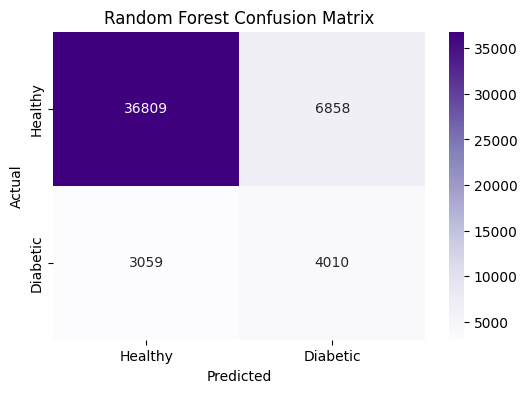

In [109]:
cm = confusion_matrix(y_test, rf_test_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Healthy', 'Diabetic'], yticklabels=['Healthy', 'Diabetic'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest Confusion Matrix')
plt.show()

Feature Importance

/var/folders/qz/mv_4p68n4lb9prgykyswxzdr0000gn/T/ipykernel_71818/1793906244.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=xgboost_importances.head(5), x='Importance', y='Feature', palette='Blues_r')


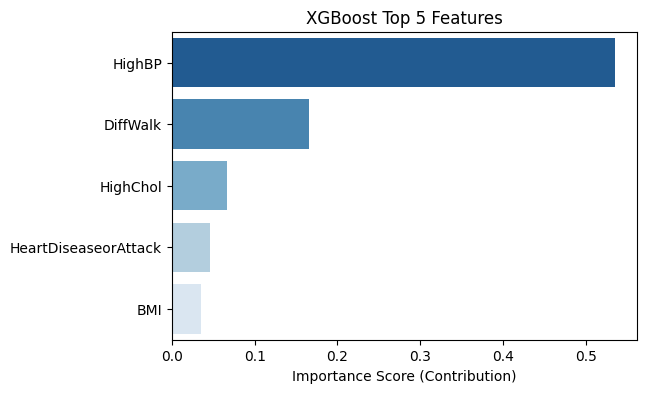

In [110]:
xgboost_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xg_model.feature_importances_
})

xgboost_importances = xgboost_importances.sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(6, 4))
sns.barplot(data=xgboost_importances.head(5), x='Importance', y='Feature', palette='Blues_r')
plt.title('XGBoost Top 5 Features')
plt.xlabel('Importance Score (Contribution)')
plt.ylabel('')
plt.show()

/var/folders/qz/mv_4p68n4lb9prgykyswxzdr0000gn/T/ipykernel_71818/707273544.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importances.head(5), x='Importance', y='Feature', palette='Purples_r')


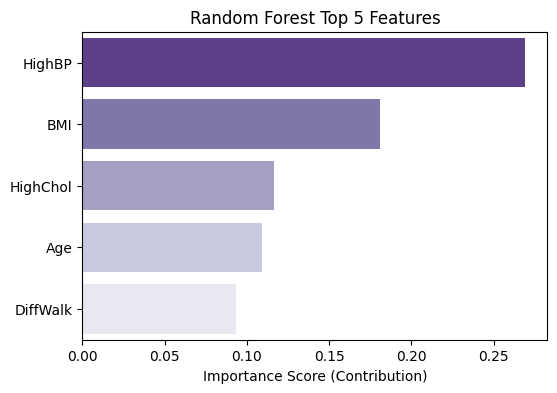

In [111]:
rf_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
rf_importances = rf_importances.sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(6, 4))
sns.barplot(data=rf_importances.head(5), x='Importance', y='Feature', palette='Purples_r')
plt.title('Random Forest Top 5 Features')
plt.xlabel('Importance Score (Contribution)')
plt.ylabel('')
plt.show()

/var/folders/qz/mv_4p68n4lb9prgykyswxzdr0000gn/T/ipykernel_71818/1695352190.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=xgboost_importances.head(5), x='Importance', y='Feature', palette='Blues_r', ax=axes[0])
/var/folders/qz/mv_4p68n4lb9prgykyswxzdr0000gn/T/ipykernel_71818/1695352190.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importances.head(5), x='Importance', y='Feature', palette='Purples_r', ax=axes[1])


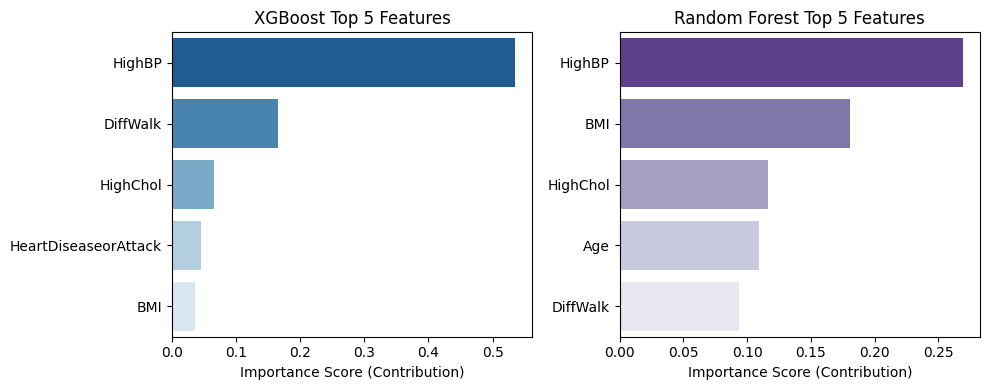

In [112]:
# Create a figure and a set of subplots (1 row, 2 columns)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4)) #

# plot xgboost feature importance
xgboost_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xg_model.feature_importances_
})

xgboost_importances = xgboost_importances.sort_values('Importance', ascending=False).reset_index(drop=True)

sns.barplot(data=xgboost_importances.head(5), x='Importance', y='Feature', palette='Blues_r', ax=axes[0])
axes[0].set_title('XGBoost Top 5 Features')
axes[0].set_xlabel('Importance Score (Contribution)')
axes[0].set_ylabel('')

# plot rf feature importance
rf_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
rf_importances = rf_importances.sort_values('Importance', ascending=False).reset_index(drop=True)

sns.barplot(data=rf_importances.head(5), x='Importance', y='Feature', palette='Purples_r', ax=axes[1])
axes[1].set_title('Random Forest Top 5 Features')
axes[1].set_xlabel('Importance Score (Contribution)')
axes[1].set_ylabel('')

plt.tight_layout() 
plt.show()

In [ ]:
# for row in rf_importances.itertuples():
    # print(f"{row.Feature}: {row.Importance:.6f}")

Precision-Recall Curves

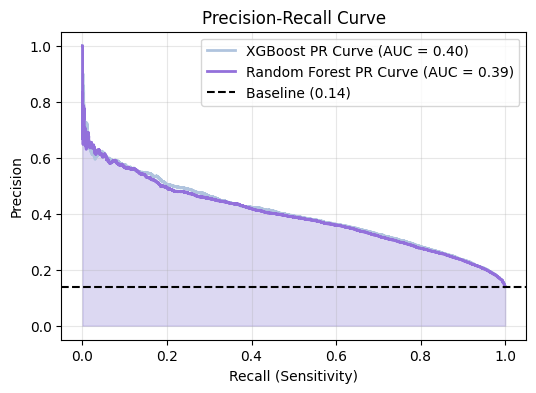

In [113]:
xg_precision, xg_recall, xg_thresholds = precision_recall_curve(y_test, xg_test_probs)
rf_precision, rf_recall, rf_thresholds = precision_recall_curve(y_test, rf_test_probs)
xg_pr_auc = auc(xg_recall, xg_precision)
rf_pr_auc = auc(rf_recall, rf_precision)

plt.figure(figsize=(6, 4))
plt.plot(xg_recall, xg_precision, color='lightsteelblue', lw=2, label=f'XGBoost PR Curve (AUC = {xg_pr_auc:.2f})')
plt.plot(rf_recall, rf_precision, color='mediumpurple', lw=2, label=f'Random Forest PR Curve (AUC = {rf_pr_auc:.2f})')

plt.fill_between(xg_recall, xg_precision, alpha=0.2, color='lightsteelblue')
plt.fill_between(rf_recall, rf_precision, alpha=0.2, color='mediumpurple')

# add a baseline for a random model (ratio of positive cases)
baseline_value = (y_test.sum() / len(y_test)).item()

plt.axhline(y=baseline_value, color='black', linestyle='--', label=f'Baseline ({baseline_value:.2f})')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()

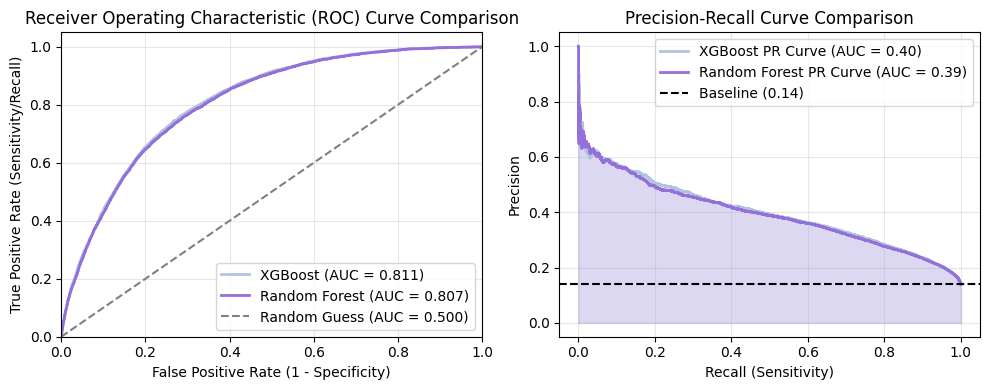

In [114]:
# Create a figure and a set of subplots (1 row, 2 columns)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4)) #

# plot ROC curves
# plot xgboost
axes[0].plot(xgb_fpr, xgb_tpr, color='lightsteelblue', lw=2, 
         label=f'XGBoost (AUC = {xgb_auc:.3f})')
# plot random forest
axes[0].plot(rf_fpr, rf_tpr, color='mediumpurple', lw=2, 
         label=f'Random Forest (AUC = {rf_auc:.3f})')
# plot the "Random Guess" diagonal line
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.500)')

# format plot
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity/Recall)')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve Comparison')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# plot PR curves
axes[1].plot(xg_recall, xg_precision, color='lightsteelblue', lw=2, label=f'XGBoost PR Curve (AUC = {xg_pr_auc:.2f})')
axes[1].plot(rf_recall, rf_precision, color='mediumpurple', lw=2, label=f'Random Forest PR Curve (AUC = {rf_pr_auc:.2f})')
axes[1].fill_between(xg_recall, xg_precision, alpha=0.2, color='lightsteelblue')
axes[1].fill_between(rf_recall, rf_precision, alpha=0.2, color='mediumpurple')

baseline_value = (y_test.sum() / len(y_test)).item()

axes[1].axhline(y=baseline_value, color='black', linestyle='--', label=f'Baseline ({baseline_value:.2f})')

axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)


plt.tight_layout() 
plt.show()

Calibration Curve

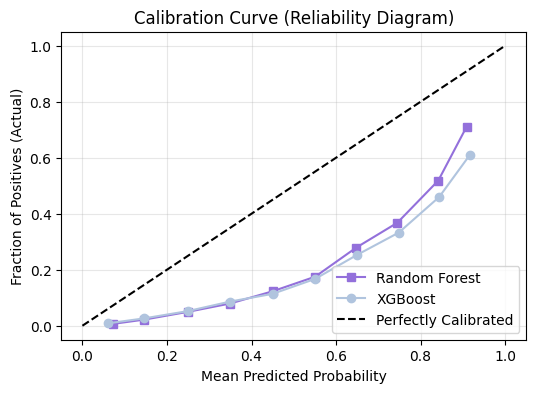

In [115]:
rf_test_probs = rf_model.predict_proba(X_test)[:, 1]
rf_prob_true, rf_prob_pred = calibration_curve(y_test, rf_test_probs, n_bins=10)

xg_test_probs = xg_model.predict_proba(X_test)[:, 1]
xg_prob_true, xg_prob_pred = calibration_curve(y_test, xg_test_probs, n_bins=10)

plt.figure(figsize=(6, 4))
plt.plot(rf_prob_pred, rf_prob_true, marker='s', label='Random Forest', color='mediumpurple')
plt.plot(xg_prob_pred, xg_prob_true, marker='o', label='XGBoost', color='lightsteelblue')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated', color='black')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual)')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

calculate 95% CI with bootstrapping method

In [123]:
import numpy as np
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss, 
                             f1_score, recall_score, precision_score, confusion_matrix)

def get_full_paired_analysis(y_true, probs_a, probs_b, threshold_a, threshold_b, n_bootstraps=1000):
    metrics_list = ['roc_auc', 'pr_auc', 'brier', 'sens', 'spec', 'prec', 'f1']
    
    # Storage for raw bootstrap distributions
    raw_scores = {
        'model_a': {m: [] for m in metrics_list},
        'model_b': {m: [] for m in metrics_list},
        'deltas':  {m: [] for m in metrics_list}
    }
    
    rng = np.random.RandomState(42)
    y_true = np.array(y_true).flatten()
    probs_a = np.array(probs_a).flatten()
    probs_b = np.array(probs_b).flatten()

    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y_true), len(y_true))
        y_true_boot = y_true[indices]
        
        if len(np.unique(y_true_boot)) < 2: continue

        # --- Data extraction for this fold ---
        p_a, p_b = probs_a[indices], probs_b[indices]
        y_a, y_b = (p_a >= threshold_a).astype(int), (p_b >= threshold_b).astype(int)
        
        # --- Metric Calculation Helpers ---
        def get_metrics(y_t, p_scores, y_preds):
            tn, fp, fn, tp = confusion_matrix(y_t, y_preds).ravel()
            return {
                'roc_auc': roc_auc_score(y_t, p_scores),
                'pr_auc':  average_precision_score(y_t, p_scores),
                'brier':   brier_score_loss(y_t, p_scores),
                'sens':    recall_score(y_t, y_preds),
                'spec':    tn / (tn + fp),
                'prec':    precision_score(y_t, y_preds, zero_division=0),
                'f1':      f1_score(y_t, y_preds, zero_division=0)
            }

        res_a = get_metrics(y_true_boot, p_a, y_a)
        res_b = get_metrics(y_true_boot, p_b, y_b)

        # --- Store results and calculate paired Delta ---
        for m in metrics_list:
            raw_scores['model_a'][m].append(res_a[m])
            raw_scores['model_b'][m].append(res_b[m])
            raw_scores['deltas'][m].append(res_a[m] - res_b[m]) # Paired Difference
    
    # --- Final Summary Statistics ---
    summary = {}
    for m in metrics_list:
        # P-value calculation (two-tailed)
        d = np.array(raw_scores['deltas'][m])
        p_val = 2 * min(np.mean(d <= 0), np.mean(d >= 0))
        
        # CI of the Difference
        d_mean = np.mean(d)
        d_low, d_high = np.percentile(d, [2.5, 97.5])
        
        summary[m] = {
            'p_value': p_val,
            'delta_mean': d_mean,
            'delta_ci': (d_low, d_high),
            'model_a_ci': (np.percentile(raw_scores['model_a'][m], 2.5), np.percentile(raw_scores['model_a'][m], 97.5)),
            'model_b_ci': (np.percentile(raw_scores['model_b'][m], 2.5), np.percentile(raw_scores['model_b'][m], 97.5))
        }
        
    return summary

In [124]:
# 1. Define your optimal thresholds (from your previous work)
threshold_xgb = 0.6357
threshold_rf = 0.6201

# 2. Call the function
# This will run 1,000 simulations where both models are tested on the same data slices
analysis_results = get_full_paired_analysis(
    y_true=y_test, 
    probs_a=xg_test_probs,  # XGBoost probabilities
    probs_b=rf_test_probs,  # Random Forest probabilities
    threshold_a=threshold_xgb, 
    threshold_b=threshold_rf, 
    n_bootstraps=1000
)

In [125]:
# Loop through the metrics to see the "Delta CI" and "P-value"
for metric, stats in analysis_results.items():
    print(f"--- {metric.upper()} ---")
    print(f"Paired Difference Mean: {stats['delta_mean']:.4f}")
    print(f"95% CI of Difference:  [{stats['delta_ci'][0]:.4f}, {stats['delta_ci'][1]:.4f}]")
    print(f"P-value:               {stats['p_value']:.4f}")
    
    # Check if significant (if CI does not cross 0)
    is_sig = "YES" if (stats['delta_ci'][0] > 0 or stats['delta_ci'][1] < 0) else "NO"
    print(f"Statistically Significant? {is_sig}")
    print("\n")

--- ROC_AUC ---
Paired Difference Mean: 0.0038
95% CI of Difference:  [0.0028, 0.0048]
P-value:               0.0000
Statistically Significant? YES


--- PR_AUC ---
Paired Difference Mean: 0.0059
95% CI of Difference:  [0.0029, 0.0090]
P-value:               0.0000
Statistically Significant? YES


--- BRIER ---
Paired Difference Mean: 0.0043
95% CI of Difference:  [0.0040, 0.0047]
P-value:               0.0000
Statistically Significant? YES


--- SENS ---
Paired Difference Mean: 0.0275
95% CI of Difference:  [0.0218, 0.0330]
P-value:               0.0000
Statistically Significant? YES


--- SPEC ---
Paired Difference Mean: -0.0113
95% CI of Difference:  [-0.0130, -0.0096]
P-value:               0.0000
Statistically Significant? YES


--- PREC ---
Paired Difference Mean: -0.0052
95% CI of Difference:  [-0.0083, -0.0016]
P-value:               0.0040
Statistically Significant? YES


--- F1 ---
Paired Difference Mean: 0.0043
95% CI of Difference:  [0.0005, 0.0084]
P-value:               0

In [126]:
import pauc # or from MLstatkit import Delong_test

# 2. If using pAUC:
roc_xgb = pauc.ROC(np.squeeze(y_test.values.T), xg_test_probs, name="XGBoost")
roc_rf = pauc.ROC(np.squeeze(y_test.values.T), rf_test_probs, name="Random Forest")

# 3. Perform the comparison
comparison = pauc.compare(roc_xgb, roc_rf, method="delong")

print(comparison)

DeLong's test for two correlated ROC curves

data:  XGBoost and Random Forest
Z = 7.387, p-value = 0.000
alternative hypothesis: true difference in AUC is not equal to 0
95 percent confidence interval:
 0.003 0.005
sample estimates:
AUC of XGBoost AUC of Random Forest
      0.811       0.807


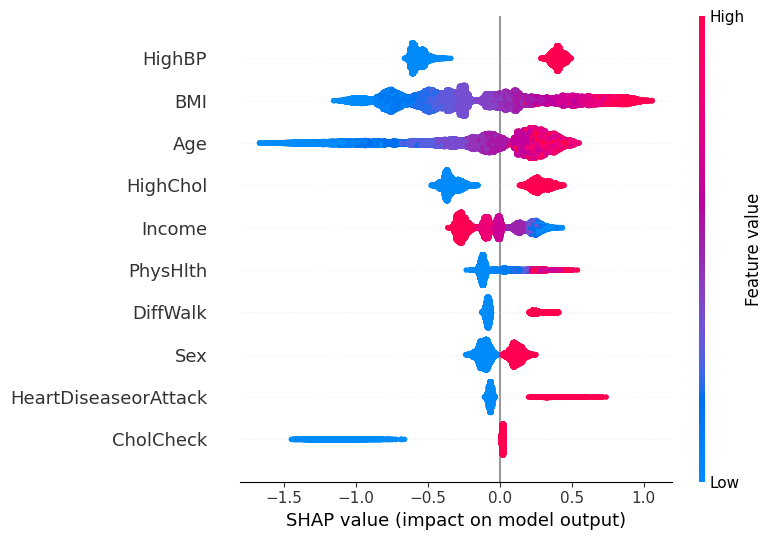

In [127]:

# create the explainer (TreeExplainer is the fastest and most accurate for tree models)
xg_explainer = shap.TreeExplainer(xg_model)

# calculate SHAP values
xg_shap_values = xg_explainer.shap_values(X_test)

# summary plot shows the magnitude and direction of feature impacts
shap.summary_plot(xg_shap_values, X_test, max_display = 10)

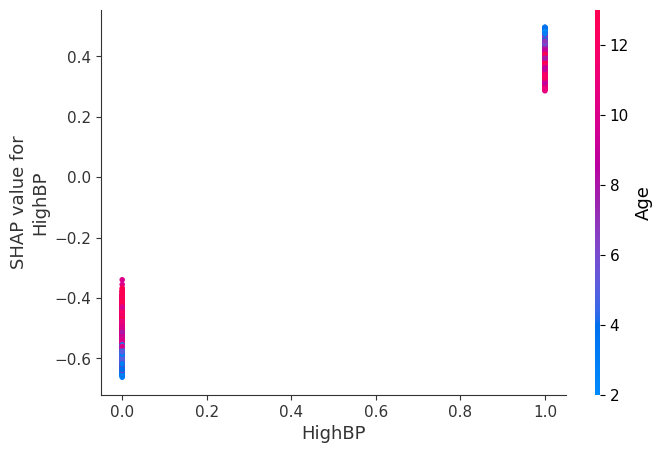

In [128]:
shap.dependence_plot("HighBP", xg_shap_values, X_test)

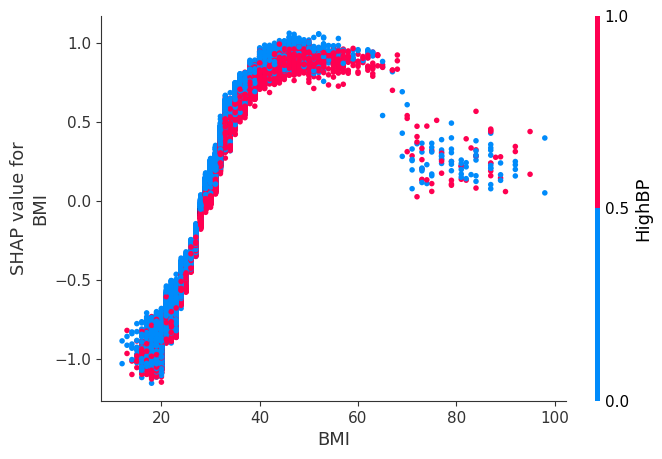

In [129]:
shap.dependence_plot("BMI", xg_shap_values, X_test)

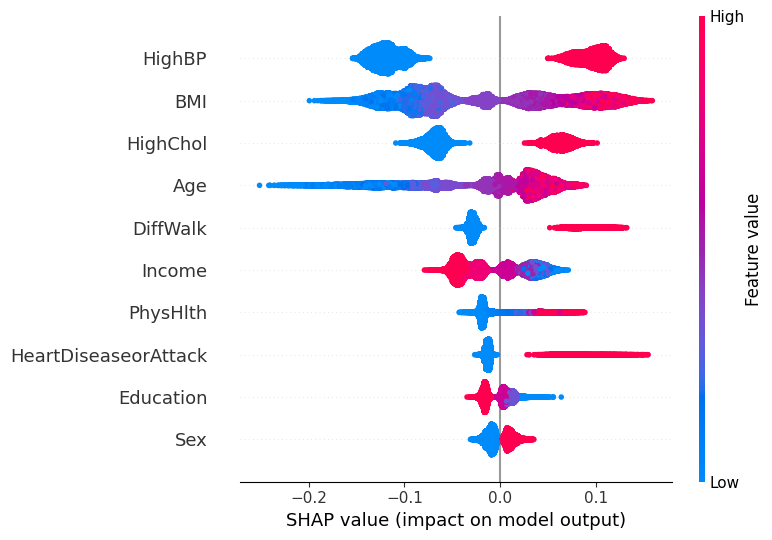

In [130]:
# this takes ~15 minutes

# create the explainer (TreeExplainer is the fastest and most accurate for tree models)
rf_explainer = shap.TreeExplainer(rf_model)

# calculate SHAP values
rf_shap_values = rf_explainer.shap_values(X_test)
rf_shap_pos = rf_shap_values[:, :, 1]

# summary plot shows the magnitude and direction of feature impacts
shap.summary_plot(rf_shap_pos, X_test, max_display=10)

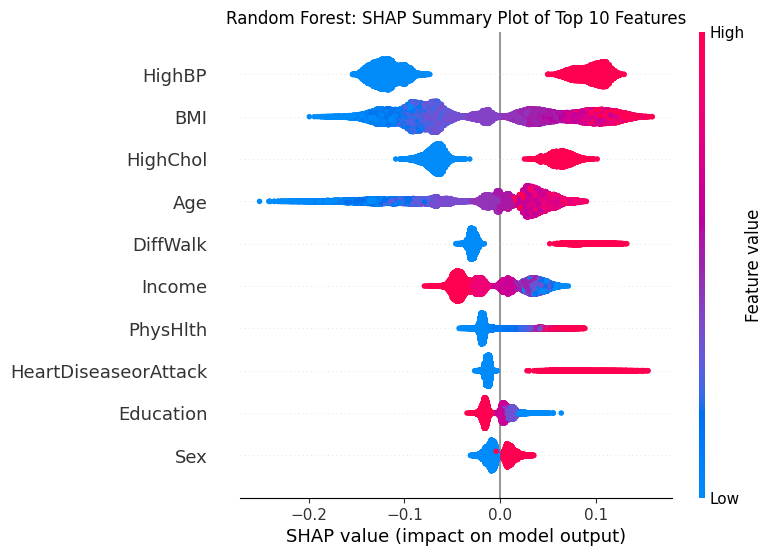

In [131]:
# random forest shap plot will all features for supplemental
plt.figure()
shap.summary_plot(rf_shap_pos, X_test,show=False,max_display=10)
plt.title("Random Forest: SHAP Summary Plot of Top 10 Features")
plt.show()

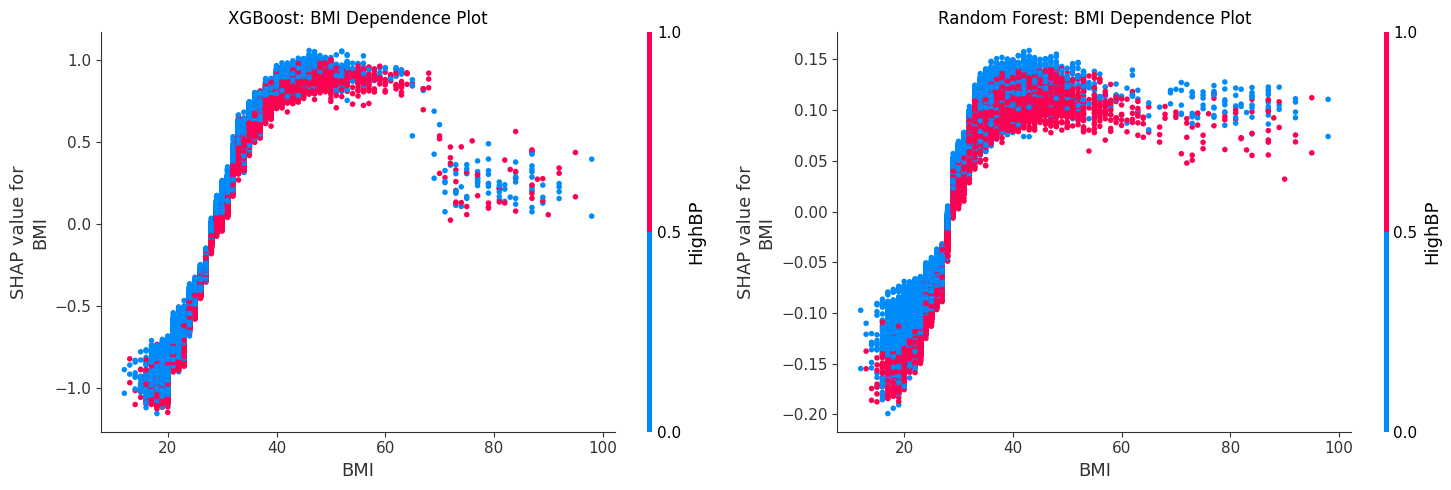

In [132]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Feature A on the first axis
shap.dependence_plot("BMI", xg_shap_values, X_test, ax=ax1, show=False)
ax1.set_title("XGBoost: BMI Dependence Plot")
# Plot Feature B on the second axis
# By default, SHAP picks the best interaction feature to color the dots
shap.dependence_plot("BMI", rf_shap_pos, X_test, ax=ax2, show=False)
ax2.set_title("Random Forest: BMI Dependence Plot")

plt.tight_layout()
plt.show()

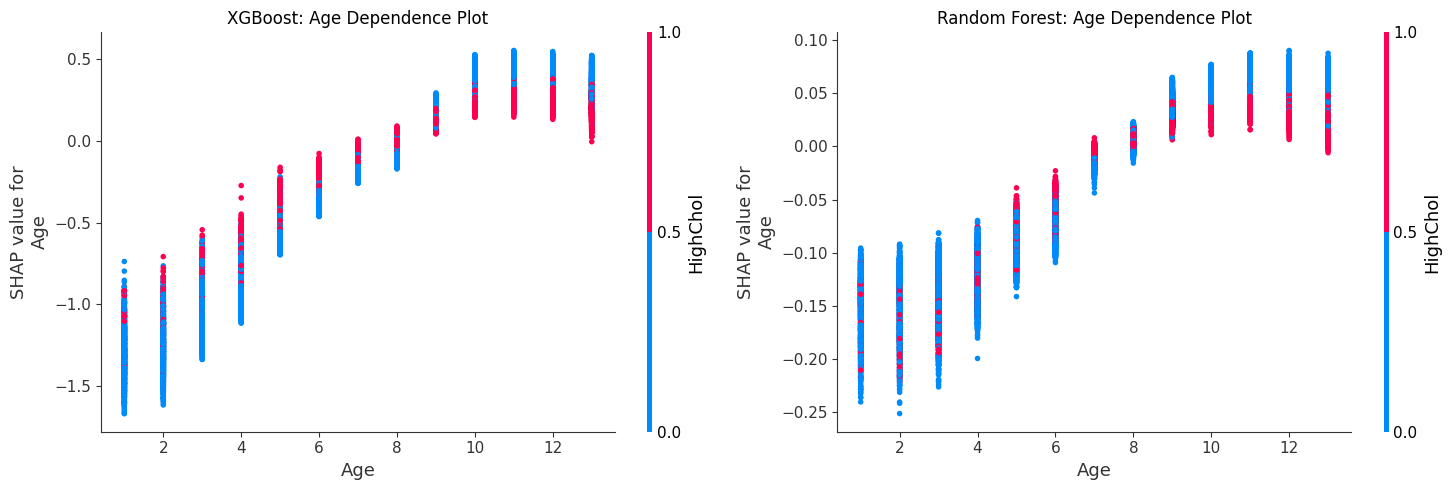

In [133]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Feature A on the first axis
shap.dependence_plot("Age", xg_shap_values, X_test, ax=ax1, show=False)
ax1.set_title("XGBoost: Age Dependence Plot")
# Plot Feature B on the second axis
# By default, SHAP picks the best interaction feature to color the dots
shap.dependence_plot("Age", rf_shap_pos, X_test, ax=ax2, show=False)
ax2.set_title("Random Forest: Age Dependence Plot")

plt.tight_layout()
plt.show()

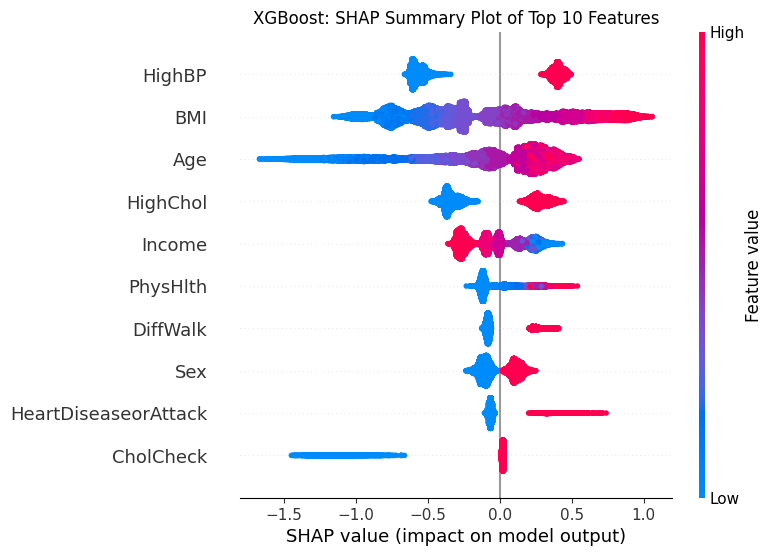

In [134]:
# xgb shap plot will all features for supplemental
plt.figure()
shap.summary_plot(xg_shap_values, X_test,show=False,max_display=10)
plt.title("XGBoost: SHAP Summary Plot of Top 10 Features")
plt.show()

#### Comparing AUC - Delong's Test

[this code is from Yandex Data School ROC comparison code]

In [135]:
import scipy

def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N)

    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5*(i+j-1)
        i = j

    T2 = np.empty(N)
    T2[J] = T + 1
    return T2


def fast_delong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m+n])

    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])

    aucs = tz[:, :m].sum(axis=1)/m/n - (m+1.0)/2.0/n

    v01 = (tz[:, :m] - tx)/n
    v10 = 1.0 - (tz[:, m:] - ty)/m

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = sx/m + sy/n
    return aucs, delongcov


def delong_roc_test(y_true, pred1, pred2):
    order = np.argsort(-y_true)
    label_1_count = int(np.sum(y_true))

    predictions = np.vstack((pred1, pred2))[:, order]

    aucs, delongcov = fast_delong(predictions, label_1_count)

    diff = aucs[0] - aucs[1]
    var = delongcov[0,0] + delongcov[1,1] - 2*delongcov[0,1]
    z = np.abs(diff) / np.sqrt(var)

    p = 2 * (1 - scipy.stats.norm.cdf(z))
    return p

In [136]:
flat_array =  y_test.to_numpy().ravel()
p_value = delong_roc_test(flat_array, rf_test_probs, xg_test_probs)
print("DeLong p-value:", p_value)

DeLong p-value: 1.503241975342462e-13


#### Error Analysis

In [137]:
# fixing age column to have better numbers
age_label = ['18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80 or older']
age_mapping = {i: label for i, label in enumerate(age_label, start=1)}
X_test['Age_Group'] = X_test['Age'].map(age_mapping)
X_test.head(2)

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Age_Group
128677,1,1,1,28,0,0,0,1,1,1,...,1,0,0,0,0,1,5,5,8,40-44
225051,1,0,1,36,1,0,0,0,0,1,...,1,1,0,0,1,0,10,3,4,65-69


In [138]:
xg_results = pd.DataFrame({
    "true": flat_array,
    "pred": xg_test_preds,
    "Age": X_test["Age_Group"],
    "HighBP": X_test["HighBP"],
    "BMI": X_test["BMI"],
    "HighChol": X_test["HighChol"]
})
xg_results["error"] = xg_results["true"] != xg_results["pred"]
rf_results = pd.DataFrame({
    "true": flat_array,
    "pred": rf_test_preds,
    "Age": X_test["Age_Group"],
    "HighBP": X_test["HighBP"],
    "BMI": X_test["BMI"],
    "HighChol": X_test["HighChol"]
})
rf_results["error"] = rf_results["true"] != rf_results["pred"]

Blood Pressure Errors

In [139]:
print("XG Boost BP")
print(xg_results.groupby("HighBP")["error"].mean())
print("random forest BP")
print(rf_results.groupby("HighBP")["error"].mean())

XG Boost BP
HighBP
0    0.076081
1    0.368126
Name: error, dtype: float64
random forest BP
HighBP
0    0.068832
1    0.363991
Name: error, dtype: float64


Age Errors

In [140]:
print("XG Boost Age")
print(xg_results.groupby("Age")["error"].mean())
print("Random ForestAge")
print(rf_results.groupby("Age")["error"].mean())

XG Boost Age
Age
18-24          0.012428
25-29          0.019016
30-34          0.031668
35-39          0.060541
40-44          0.089636
45-49          0.114227
50-54          0.160968
55-59          0.197358
60-64          0.245863
65-69          0.286109
70-74          0.321669
75-79          0.317051
80 or older    0.322467
Name: error, dtype: float64
Random ForestAge
Age
18-24          0.011599
25-29          0.017705
30-34          0.028992
35-39          0.060180
40-44          0.081855
45-49          0.107023
50-54          0.154245
55-59          0.199505
60-64          0.244073
65-69          0.273369
70-74          0.306071
75-79          0.313671
80 or older    0.312188
Name: error, dtype: float64


Cholesterol Errors

In [141]:
# include size of each group to make sure we aren't just seeing noise from small groups
print("XG Boost Cholesterol")
print(xg_results.groupby("HighChol")["error"].mean())
print(xg_results.groupby("HighChol").size())
print("random forest Cholesterol")
print(rf_results.groupby("HighChol")["error"].mean())
print(rf_results.groupby("HighChol").size())

XG Boost Cholesterol
HighChol
0    0.114715
1    0.319399
Name: error, dtype: float64
HighChol
0    29255
1    21481
dtype: int64
random forest Cholesterol
HighChol
0    0.106648
1    0.316419
Name: error, dtype: float64
HighChol
0    29255
1    21481
dtype: int64


BMI Errors

In [142]:
xg_results["BMI_bin"] = pd.cut(xg_results["BMI"], bins=5)
xg_results.groupby("BMI_bin")["error"].mean()

/var/folders/qz/mv_4p68n4lb9prgykyswxzdr0000gn/T/ipykernel_71818/1290387311.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  xg_results.groupby("BMI_bin")["error"].mean()


BMI_bin
(11.914, 29.2]    0.127766
(29.2, 46.4]      0.337567
(46.4, 63.6]      0.412857
(63.6, 80.8]      0.296296
(80.8, 98.0]      0.177419
Name: error, dtype: float64

In [143]:
rf_results["BMI_bin"] = pd.cut(rf_results["BMI"], bins=5)
rf_results.groupby("BMI_bin")["error"].mean()

/var/folders/qz/mv_4p68n4lb9prgykyswxzdr0000gn/T/ipykernel_71818/2341799876.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rf_results.groupby("BMI_bin")["error"].mean()


BMI_bin
(11.914, 29.2]    0.124385
(29.2, 46.4]      0.327788
(46.4, 63.6]      0.374286
(63.6, 80.8]      0.308642
(80.8, 98.0]      0.209677
Name: error, dtype: float64